# YOLOv1 (pjreddie/darknet) — test image + labels avec probabilité

## 1) Patch : afficher `classe + proba` sur l’image

In [2]:
from pathlib import Path
import re

path = Path("src/image.c")
assert path.exists(), f"Introuvable: {path.resolve()}"

txt = path.read_text(encoding="utf-8", errors="ignore")

marker = "/* PATCH_SHOW_CONFIDENCE_IN_LABELSTR */"
if marker in txt:
    print("Patch déjà appliqué ✅")
else:
    pat = r'strcat\(labelstr,\s*names\[j\]\s*\);'
    rep = (
        r'do { char tmp[256]; '
        r'sprintf(tmp, "%s %.0f%%", names[j], dets[i].prob[j]*100); '
        r'strcat(labelstr, tmp); } while(0); ' + marker
    )

    n = len(re.findall(pat, txt))
    assert n > 0, "Pattern non trouvé. Cherche 'strcat(labelstr, names[j]);' dans src/image.c"
    path.write_text(re.sub(pat, rep, txt), encoding="utf-8")
    print(f"Patch appliqué ✅ ({n} remplacement(s))")


Patch déjà appliqué ✅


## 2) Compiler

In [3]:
!make clean
!make all


rm -rf ./obj/gemm.o ./obj/utils.o ./obj/cuda.o ./obj/deconvolutional_layer.o ./obj/convolutional_layer.o ./obj/list.o ./obj/image.o ./obj/activations.o ./obj/im2col.o ./obj/col2im.o ./obj/blas.o ./obj/crop_layer.o ./obj/dropout_layer.o ./obj/maxpool_layer.o ./obj/softmax_layer.o ./obj/data.o ./obj/matrix.o ./obj/network.o ./obj/connected_layer.o ./obj/cost_layer.o ./obj/parser.o ./obj/option_list.o ./obj/detection_layer.o ./obj/route_layer.o ./obj/upsample_layer.o ./obj/box.o ./obj/normalization_layer.o ./obj/avgpool_layer.o ./obj/layer.o ./obj/local_layer.o ./obj/shortcut_layer.o ./obj/logistic_layer.o ./obj/activation_layer.o ./obj/rnn_layer.o ./obj/gru_layer.o ./obj/crnn_layer.o ./obj/demo.o ./obj/batchnorm_layer.o ./obj/region_layer.o ./obj/reorg_layer.o ./obj/tree.o ./obj/lstm_layer.o ./obj/l2norm_layer.o ./obj/yolo_layer.o ./obj/iseg_layer.o ./obj/image_opencv.o libdarknet.so libdarknet.a darknet ./obj/captcha.o ./obj/lsd.o ./obj/super.o ./obj/art.o ./obj/tag.o ./obj/cifar.o ./ob

## 3) Poids YOLOv1 (`yolov1.weights`)

In [4]:
from pathlib import Path
import os

w = Path("yolov1.weights")
if w.exists() and w.stat().st_size > 0:
    print("OK:", w.resolve())
else:
    for url in [
        "https://pjreddie.com/media/files/yolov1.weights",
        "http://pjreddie.com/media/files/yolov1.weights",
    ]:
        print("Téléchargement:", url)
        if os.system(f"wget -O {w} {url}") == 0 and w.exists() and w.stat().st_size > 0:
            break
    assert w.exists() and w.stat().st_size > 0, "Téléchargement KO. Place yolov1.weights à la racine du repo."


OK: /mnt/d/Documents/0Polytech Sorbonne/MAIN/MAIN4/Projet industriel/darknet/yolov1.weights


## 4) Détection sur une image

In [7]:
from pathlib import Path

CFG = "cfg/yolov1.cfg"
WEIGHTS = "yolov1.weights"
IMAGE = "data/dog_bicycle_car.jpg"   # <-- remplace par ton image

assert Path(CFG).exists(), f"Config introuvable: {CFG}"
assert Path(WEIGHTS).exists(), f"Poids introuvables: {WEIGHTS}"
assert Path(IMAGE).exists(), f"Image introuvable: {IMAGE}"

# Option : ajoute -thresh 0.25
!./darknet yolo test {CFG} {WEIGHTS} {IMAGE}


layer     filters    size              input                output
    0 conv     64  7 x 7 / 2   448 x 448 x   3   ->   224 x 224 x  64  0.944 BFLOPs
    1 max          2 x 2 / 2   224 x 224 x  64   ->   112 x 112 x  64
    2 conv    192  3 x 3 / 1   112 x 112 x  64   ->   112 x 112 x 192  2.775 BFLOPs
    3 max          2 x 2 / 2   112 x 112 x 192   ->    56 x  56 x 192
    4 conv    128  1 x 1 / 1    56 x  56 x 192   ->    56 x  56 x 128  0.154 BFLOPs
    5 conv    256  3 x 3 / 1    56 x  56 x 128   ->    56 x  56 x 256  1.850 BFLOPs
    6 conv    256  1 x 1 / 1    56 x  56 x 256   ->    56 x  56 x 256  0.411 BFLOPs
    7 conv    512  3 x 3 / 1    56 x  56 x 256   ->    56 x  56 x 512  7.399 BFLOPs
    8 max          2 x 2 / 2    56 x  56 x 512   ->    28 x  28 x 512
    9 conv    256  1 x 1 / 1    28 x  28 x 512   ->    28 x  28 x 256  0.206 BFLOPs
   10 conv    512  3 x 3 / 1    28 x  28 x 256   ->    28 x  28 x 512  1.850 BFLOPs
   11 conv    256  1 x 1 / 1    28 x  28 x 512   ->

## 5) Afficher la sortie (`predictions.png` ou `predictions.jpg`)

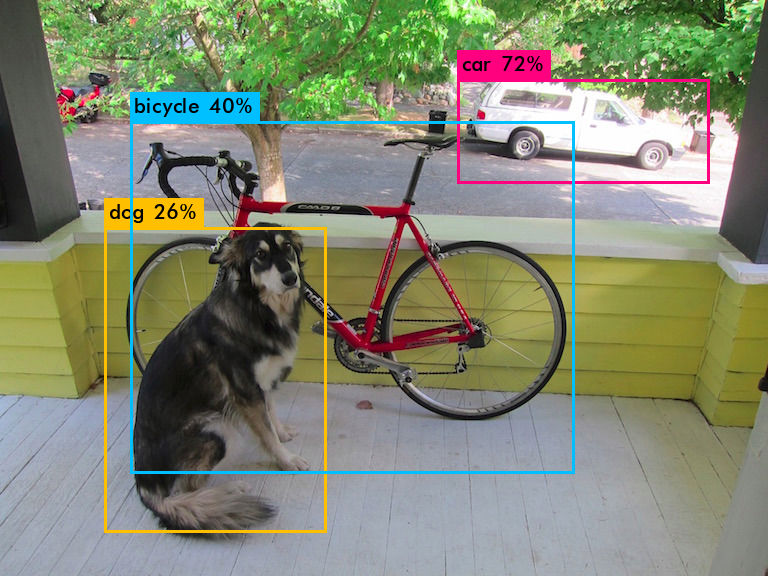

Sortie: /mnt/d/Documents/0Polytech Sorbonne/MAIN/MAIN4/Projet industriel/darknet/predictions.jpg


In [8]:
from pathlib import Path
from IPython.display import Image, display

out = next((p for p in [Path("predictions.png"), Path("predictions.jpg")] if p.exists()), None)
assert out is not None, "Aucune sortie predictions.png/jpg trouvée."
display(Image(filename=str(out)))
print("Sortie:", out.resolve())
